# 03 — Single-feature models

This notebook answers the client's question: **which single customer attribute best
predicts a claim?**

One logistic regression per feature, fitted on the 7,000-row training split and scored on
the 1,500-row validation split it never saw. Both encoding schemes. Parameter counts,
AIC, and ranking metrics reported alongside accuracy, because accuracy alone cannot tell
you whether a model found signal or learned to say "no."

The test split is still untouched. It is used once, in notebook 04.

In [1]:
import sys; sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src import config as cfg
from src.data import load_raw, split_data, majority_class_baseline
from src.features import MedianImputer
from src.models import sweep_features
from src.plots import set_style, save_fig

set_style()
pd.set_option("display.width", 200)

df = load_raw()
train, val, test = split_data(df)
imputer = MedianImputer().fit(train)          # D3: fitted on train only
baseline = majority_class_baseline(train[cfg.TARGET])

print(f"train {len(train)} | val {len(val)} | test {len(test)} (untouched)")
print(f"majority-class baseline: {baseline:.4f}")

train 7000 | val 1500 | test 1500 (untouched)
majority-class baseline: 0.6867


In [2]:
results = sweep_features(train, val, imputer=imputer, baseline=baseline)
results.to_csv(cfg.DATA_PROCESSED / "results_single_feature.csv", index=False)
print(f"{len(results)} models fitted ({results.feature.nunique()} features x {results.scheme.nunique()} schemes)")

32 models fitted (16 features x 2 schemes)


## 1. The results

Sorted by validation accuracy, dummy encoding. The `baseline` column is 68.67% throughout
— that is the accuracy of predicting "no claim" for every customer, and it is the number
every row must be read against.

In [3]:
cols = ["feature", "n_params", "accuracy", "lift_over_baseline", "roc_auc",
        "precision", "recall", "predicted_positive_rate", "aic", "separation"]
dummy = results[results.scheme == "dummy"].sort_values("accuracy", ascending=False)
dummy[cols].round(4).reset_index(drop=True)

,feature,n_params,accuracy,lift_over_baseline,roc_auc,precision,recall,predicted_positive_rate,aic,separation
0,driving_experience,3,0.7880,0.1013,0.8127,0.6490,0.7043,0.3400,6503.1745,False
1,age,3,0.7787,0.0920,0.7676,0.7379,0.4553,0.1933,7072.7825,False
2,income,3,0.7547,0.0680,0.7586,0.6932,0.3894,0.1760,7456.3586,False
3,vehicle_ownership,1,0.7447,0.0580,0.6972,0.5969,0.5702,0.2993,7721.1171,False
4,credit_score,1,0.7120,0.0253,0.6895,0.6022,0.2383,0.1240,7987.5768,False
5,postal_code,3,0.7007,0.0140,0.5648,1.0000,0.0447,0.0140,NaN,True
6,annual_mileage,1,0.6920,0.0053,0.5959,0.6538,0.0362,0.0173,8475.1573,False
7,gender,1,0.6867,-0.0000,0.5533,0.0000,0.0000,0.0000,8610.5453,False
8,education,2,0.6867,-0.0000,0.6331,0.0000,0.0000,0.0000,8486.0124,False
9,vehicle_year,1,0.6867,-0.0000,0.6474,0.0000,0.0000,0.0000,8003.2120,False


### The headline

**`driving_experience` wins: 78.80% validation accuracy against a 68.67% baseline — a
lift of 10.13 points — with a ROC-AUC of 0.813.**

The reference implementation's conclusion was right. Its evidence was not: 77.71%
measured in-sample, with no baseline stated, so a reader could not tell whether it
represented ten points of signal or none. Rebuilding the evaluation confirms the answer
rather than overturning it, which is the more common outcome of doing this kind of work
and worth saying plainly.

`driving_experience` also wins under **every** metric in the table and under **both**
encoding schemes. That robustness is itself the finding — the recommendation does not
depend on which yardstick the client happens to prefer.

## 2. Nine of sixteen features never predict a claim at all

Look at the `predicted_positive_rate` column. Nine features score **exactly** 68.67% —
not approximately, exactly — with precision and recall of zero.

Those models predict "no claim" for all 1,500 validation customers. They score the
baseline because they *are* the baseline. Accuracy cannot distinguish them from a model
that has learned nothing, because there is nothing to distinguish.

In [4]:
flat = dummy[dummy.predicted_positive_rate == 0]
print(f"{len(flat)} of {len(dummy)} features never predict a single claim:\n")
print(flat[["feature", "accuracy", "roc_auc", "predicted_positive_rate"]]
      .sort_values("roc_auc", ascending=False).round(4).to_string(index=False))

9 of 16 features never predict a single claim:

            feature  accuracy  roc_auc  predicted_positive_rate
speeding_violations    0.6867   0.7318                      0.0
     past_accidents    0.6867   0.7258                      0.0
            married    0.6867   0.6496                      0.0
       vehicle_year    0.6867   0.6474                      0.0
          education    0.6867   0.6331                      0.0
           children    0.6867   0.6123                      0.0
               duis    0.6867   0.5980                      0.0
             gender    0.6867   0.5533                      0.0
       vehicle_type    0.6867   0.4945                      0.0


This happens because a feature can shift the predicted probability substantially without
ever pushing it across 0.5. Moving a group from a 31% claim rate to a 46% claim rate is a
real, useful change in risk — and every one of those customers is still classified "no
claim." Accuracy at a fixed threshold is blind to it.

Two of those nine are not weak features at all.

findfont: Failed to find font weight semibold, now using 700.


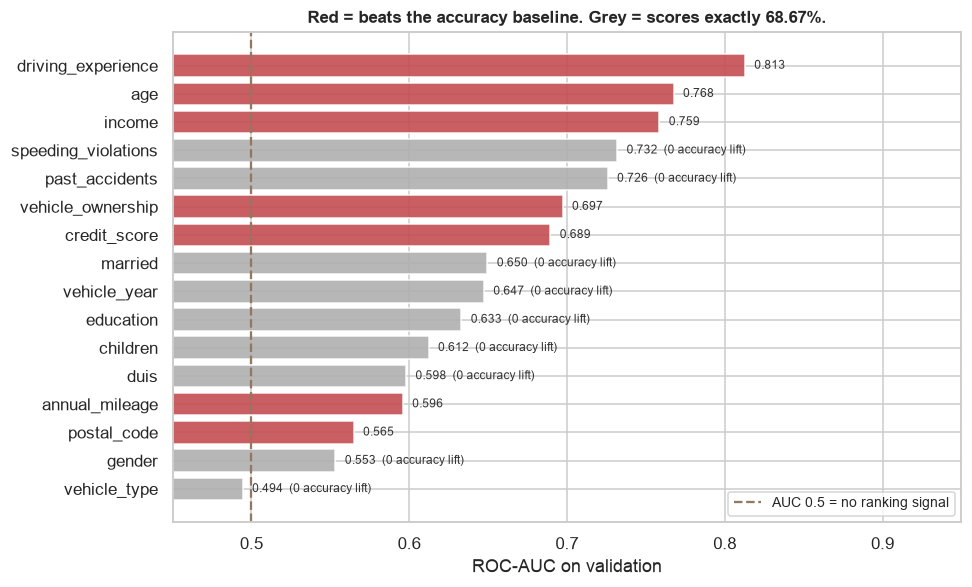

In [5]:
fig, ax = plt.subplots(figsize=(9, 5.5))
d = dummy.sort_values("roc_auc")
colors = ["#C44E52" if r > 0 else "#B0B0B0" for r in d.lift_over_baseline]
ax.barh(d.feature, d.roc_auc, color=colors, alpha=0.9)
ax.axvline(0.5, color="#937860", ls="--", lw=1.5, label="AUC 0.5 = no ranking signal")
for i, (auc, lift) in enumerate(zip(d.roc_auc, d.lift_over_baseline)):
    ax.text(auc + 0.006, i, f"{auc:.3f}" + ("" if lift > 0 else "  (0 accuracy lift)"),
            va="center", fontsize=8, color="#333")
ax.set_xlim(0.45, 0.95)
ax.set_xlabel("ROC-AUC on validation")
ax.set_title("Red = beats the accuracy baseline. Grey = scores exactly 68.67%.", fontsize=11)
ax.legend(loc="lower right", fontsize=9)
fig.tight_layout()
save_fig(fig, "auc_vs_accuracy_lift")
plt.show()

`speeding_violations` has an **AUC of 0.732** and `past_accidents` **0.726**. Both rank
customers by risk about as well as `income` does. Both deliver **zero** accuracy lift.

This is defect D5 in a single picture. The metric you choose determines the answer you
get, and the reference chose the one metric that cannot see these two features at all.

In [6]:
by_acc = dummy.sort_values("accuracy", ascending=False).feature.tolist()
by_auc = dummy.sort_values("roc_auc", ascending=False).feature.tolist()
pd.DataFrame({"rank": range(1, 7),
              "by accuracy": by_acc[:6],
              "by ROC-AUC": by_auc[:6]})

,rank,by accuracy,by ROC-AUC
0,1,driving_experience,driving_experience
1,2,age,age
2,3,income,income
3,4,vehicle_ownership,speeding_violations
4,5,credit_score,past_accidents
5,6,postal_code,vehicle_ownership


The top three agree. Ranks four and five do not: `speeding_violations` and
`past_accidents` displace `vehicle_ownership` and `credit_score` under AUC.

For this client the accuracy ranking is the one that answers their question, since they
asked for a single feature to threshold on. But an insurer pricing premiums cares about
ordering customers by risk, not about a binary flag — and for that job the AUC column is
the right one. Notebook 04 makes the cost of that choice explicit.

## 3. Does the encoding scheme change the answer? (D4)

Session 2 built an explicit feature taxonomy to fix the reference's dtype-driven
encoding, in which `driving_experience` silently became 3 parameters while `age` stayed
at 1. With both schemes now applied uniformly, the question is what that fix bought.

In [7]:
pivot = results.pivot(index="feature", columns="scheme",
                      values=["accuracy", "roc_auc", "aic"])
ordinals = pivot.loc[list(cfg.ORDINAL_LEVELS)]
ordinals["aic_gain_from_dummy"] = ordinals[("aic", "linear")] - ordinals[("aic", "dummy")]
ordinals.round(4)

accuracy         roc_auc                aic            aic_gain_from_dummy
scheme                dummy  linear   dummy  linear      dummy     linear                    
feature                                                                                      
age                  0.7787  0.7787  0.7676  0.7676  7072.7825  7126.2874             53.5049
driving_experience   0.7880  0.7880  0.8127  0.8127  6503.1745  6503.8712              0.6967
education            0.6867  0.6867  0.6331  0.6331  8486.0124  8484.8198             -1.1926
income               0.7547  0.7547  0.7586  0.7603  7456.3586  7453.8806             -2.4781

In [8]:
same_rank = (results[results.scheme == "linear"].sort_values("accuracy", ascending=False).feature.tolist()
             == results[results.scheme == "dummy"].sort_values("accuracy", ascending=False).feature.tolist())
print("linear and dummy produce the same accuracy ranking:", same_rank)
print()
print("top 5, linear:", results[results.scheme == 'linear'].nlargest(5, 'accuracy').feature.tolist())
print("top 5, dummy :", results[results.scheme == 'dummy'].nlargest(5, 'accuracy').feature.tolist())

linear and dummy produce the same accuracy ranking: True

top 5, linear: ['driving_experience', 'age', 'income', 'vehicle_ownership', 'credit_score']
top 5, dummy : ['driving_experience', 'age', 'income', 'vehicle_ownership', 'credit_score']


### The honest answer: the fix did not change the ranking

Both schemes give identical accuracy for every feature, and the same ordering. The defect
was real, the fix was correct, and **it did not change who wins.**

That is worth reporting as it stands rather than quietly dropping. The reason it does not
matter here is specific and checkable.

In [9]:
# The probabilities genuinely differ between schemes. The class predictions do not.
import statsmodels.api as sm
from src.features import build_design

tr, va = imputer.transform(train), imputer.transform(val)
rows = []
for f in cfg.ORDINAL_LEVELS:
    probs = {}
    for s in ("linear", "dummy"):
        X_tr = sm.add_constant(build_design(tr, [f], s))
        X_va = sm.add_constant(build_design(va, [f], s), has_constant="add")[X_tr.columns]
        probs[s] = sm.Logit(tr[cfg.TARGET], X_tr).fit(disp=0).predict(X_va).to_numpy()
    rows.append({
        "feature": f,
        "max_prob_difference": np.abs(probs["linear"] - probs["dummy"]).max(),
        "identical_class_predictions": ((probs["linear"] >= .5) == (probs["dummy"] >= .5)).mean(),
    })
pd.DataFrame(rows).round(4)

,feature,max_prob_difference,identical_class_predictions
0,age,0.0497,1.0
1,driving_experience,0.0082,1.0
2,education,0.0062,1.0
3,income,0.0104,1.0


The two encodings produce measurably different probabilities — up to 0.050 apart on
`age`. But for each of these features only one level sits above a 50% claim rate, and
both schemes agree on which one. Every customer therefore lands on the same side of the
threshold, and accuracy records no difference at all.

So D4 was a genuine defect that the client's chosen metric is too blunt to detect. AIC is
not too blunt.

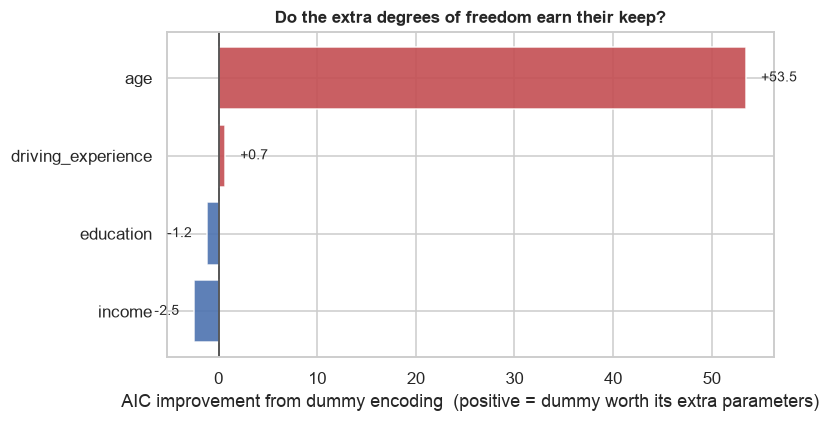

In [10]:
fig, ax = plt.subplots(figsize=(7.5, 4))
gain = ordinals["aic_gain_from_dummy"].sort_values()
ax.barh(gain.index, gain.values,
        color=["#4C72B0" if v < 0 else "#C44E52" for v in gain.values], alpha=0.9)
ax.axvline(0, color="#333", lw=1)
for i, v in enumerate(gain.values):
    ax.text(v + (1.5 if v >= 0 else -1.5), i, f"{v:+.1f}", va="center",
            ha="left" if v >= 0 else "right", fontsize=9)
ax.set_xlabel("AIC improvement from dummy encoding  (positive = dummy worth its extra parameters)")
ax.set_title("Do the extra degrees of freedom earn their keep?", fontsize=11)
fig.tight_layout()
save_fig(fig, "aic_encoding_gain")
plt.show()

This confirms a prediction made in notebook 02 **before** these models were fitted.

Session 2 plotted log-odds across ordinal levels and observed that `income` and
`education` were near-straight while `age` and `driving_experience` bent. Linear encoding
assumes straightness; where it holds, the extra dummy parameters are wasted.

That is exactly what happened. `age` gains **53.5 AIC points** from dummy encoding — its
log-odds curve was the most bent. `income` and `education` *lose* 2.5 and 1.2 points,
because their straight lines never needed the extra parameters. `driving_experience`
lands at +0.7, effectively a tie.

The prediction was made in advance and the data confirmed it. That is a stronger claim
than noticing the pattern afterwards.

## 4. `postal_code` — the feature that must not ship

Session 1 found that all 120 customers in postal code 21217 filed a claim, causing
perfect separation. Here is what that looks like as a model.

In [11]:
pc = dummy[dummy.feature == "postal_code"].iloc[0]
print(f"accuracy   {pc.accuracy:.4f}   (lift +{pc.lift_over_baseline:.4f})")
print(f"precision  {pc.precision:.4f}")
print(f"recall     {pc.recall:.4f}")
print(f"roc_auc    {pc.roc_auc:.4f}")
print(f"converged  {pc.converged}")
print(f"aic        {pc.aic}   <- withheld: meaningless when the likelihood diverges")
print()
print(f"predicts a claim for {pc.predicted_positive_rate:.1%} of validation customers,")
print(f"and is right every time ({int(pc.tp)} true positives, {int(pc.fp)} false positives).")

accuracy   0.7007   (lift +0.0140)
precision  1.0000
recall     0.0447
roc_auc    0.5648
converged  False
aic        nan   <- withheld: meaningless when the likelihood diverges

predicts a claim for 1.4% of validation customers,
and is right every time (21 true positives, 0 false positives).


Precision of **1.000** and recall of **0.045**. The model flags only the 21217 customers,
and it is never wrong about them — because in this dataset that postal code *is* the
outcome.

It clears the baseline by 1.4 points and it is worthless. The 100% claim rate is an
artifact of how the data was generated, not a fact about drivers in Baltimore, and a
model built on it would fail the moment it met a real customer from that postal code who
did not claim. Its AIC is withheld rather than reported, because a diverged likelihood
does not have a meaningful one.

Recorded here as a warning, excluded from the recommendation.

## 5. Harness check

`vehicle_type` was designated the canary in notebook 01: 95% sedan, with near-identical
claim rates across the two categories. If a feature carrying no information were to post
a real accuracy lift, the harness would be broken.

In [12]:
canary = dummy[dummy.feature == "vehicle_type"].iloc[0]
print(f"vehicle_type: accuracy {canary.accuracy:.4f}, lift {canary.lift_over_baseline:+.4f}, AUC {canary.roc_auc:.4f}")
assert canary.lift_over_baseline <= 0, "canary beat the baseline -- the harness is wrong"
assert 0.45 < canary.roc_auc < 0.55, "canary shows ranking signal it should not have"
print("PASS: the canary carries no signal, as designed.")

vehicle_type: accuracy 0.6867, lift -0.0000, AUC 0.4945
PASS: the canary carries no signal, as designed.


## 6. What carries into Session 4

- **`driving_experience` is the answer**: 78.80% validation accuracy, +10.13 points over
  baseline, AUC 0.813, winning under every metric and both encodings.
- **Accuracy is too blunt for nine of sixteen features.** `speeding_violations`
  (AUC 0.732) and `past_accidents` (AUC 0.726) rank risk well and score zero accuracy
  lift. Session 4's threshold analysis is where they get a fair hearing.
- **The encoding fix did not move the ranking** — but it moved the probabilities, and AIC
  detected what accuracy could not.
- **`postal_code` is excluded** from the recommendation and reported as a warning.
- Nothing has touched the test set yet. Session 4 scores the final choice on it **once**.